# Monte Carlo Option Pricing Simulator
## Apple (AAPL) vs Tesco (TSCO.L) — Cross Market Comparison

---

### Project Overview
This project builds a Monte Carlo Option Pricing Simulator using real
historical stock market data. Rather than using assumed theoretical values,
we download 3 years of actual market data to calculate real volatility and
drift, then simulate 1000 possible future price paths for each stock and
use those simulations to price Call and Put options.

### Why These Two Stocks?
- **Apple (AAPL)** — US technology stock listed on NASDAQ. Represents
  high growth, high volatility tech sector
- **Tesco (TSCO.L)** — UK retail stock listed on London Stock Exchange.
  Represents defensive, lower volatility consumer staples sector

Comparing a US tech stock against a UK retail stock demonstrates how
volatility differences across markets and sectors directly affect
option pricing.

### What This Project Demonstrates
- Real world financial data collection using Yahoo Finance API
- Exploratory Data Analysis (EDA) of financial time series data
- Monte Carlo simulation using Geometric Brownian Motion
- Options pricing theory — Call and Put options across three strike types
- Professional financial data visualisation using Matplotlib

### Tools & Libraries
| Tool | Purpose |
|------|---------|
| Python | Core programming language |
| yfinance | Real stock market data collection from Yahoo Finance |
| NumPy | Mathematical calculations and random number simulation |
| Matplotlib | Data visualisation and charting |
| Google Colab | Cloud based development environment |

### Project Structure
1. **Setup** — Library installation and imports
2. **Data Collection** — Download real historical price data (2022–2025)
3. **EDA Step 1** — Basic price statistics (highs, lows, averages)
4. **EDA Step 2** — Price history visualisation
5. **EDA Step 3** — Volume analysis (busiest and quietest trading days)
6. **EDA Step 4** — Daily returns and volatility calculation
7. **EDA Step 4b** — Returns distribution chart
8. **Monte Carlo Simulation** — 1000 simulated future price paths
9. **Option Pricing** — Call and Put pricing across strike types
10. **Conclusion** — Key findings and real world applications

---
*Author: Swapnil Nalawade | MSc Data Science (Distinction) — University of Essex*
*Data Source: Yahoo Finance via yfinance | Period: January 2022 — December 2025*



## Step 1 — Library Setup & Imports

### What are we installing and why?

Before writing any analysis code we need to install and import three
essential libraries. Think of libraries as toolboxes — each one gives
us a specific set of tools we would otherwise have to build from scratch.

| Library | What it does | Why we need it |
|---------|-------------|----------------|
| yfinance | Connects to Yahoo Finance and downloads real stock price data | Without this we would have to manually download CSV files |
| NumPy | Handles all mathematical operations — arrays, random numbers, statistics | Powers our Monte Carlo simulation calculations |
| Matplotlib | Creates professional charts and visualisations | Turns raw numbers into meaningful visual insights |

### Why use nicknames (yf, np, plt)?
When we write `import yfinance as yf` we give the library a short
nickname. This means instead of typing `yfinance.download()` every
time we just type `yf.download()`. Pure convenience — industry
standard practice.

### The ! symbol
`!pip install yfinance` — the exclamation mark tells Google Colab
to run this as a system command rather than Python code. It's how
we install new packages directly inside a notebook.

In [ ]:
# Install yfinance - this lets us get real stock data
!pip install yfinance

# Import our libraries
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

## Step 2 — Data Collection

### What are we doing?
Downloading 3 years of real daily stock price data for both Apple and
Tesco directly from Yahoo Finance. Every number in this project comes
from real market activity — not assumed or theoretical values.

### Why these specific dates (2022–2025)?
This 3 year window is strategically chosen because it captures a
complete market cycle:
- **2022** — Global market crash (inflation, rising interest rates,
  post-COVID correction)
- **2023** — Recovery and stabilisation period
- **2024–2025** — Bull market driven by AI excitement and economic recovery

Using a full market cycle makes our volatility calculation more
reliable than using only bull market or only bear market data.

### What does the data table show?
Each row represents one trading day. The columns are:

| Column | Meaning |
|--------|---------|
| Open | Price when market opened that morning |
| High | Highest price reached during the day |
| Low | Lowest price reached during the day |
| **Close** | Final price when market closed — our key column |
| Volume | Number of shares bought and sold that day |

### Why do we use Close price?
The closing price is the most widely used price in financial analysis
because it represents the final consensus value the market agreed on
for that day after all trading activity settled.

### Stock ticker symbols explained
- **AAPL** — Apple's ticker on NASDAQ (US market)
- **TSCO.L** — Tesco's ticker on London Stock Exchange. The **.L**
  suffix means London — without it yfinance would look for a US stock

In [ ]:
# Download real historical stock data
apple = yf.download('AAPL', start='2022-01-01', end='2025-12-31')
tesco = yf.download('TSCO.L', start='2022-01-01', end='2025-12-31')

# Look at the data
print("Apple Data:")
print(apple.tail())

print("\nTesco Data:")
print(tesco.tail())

/tmp/ipython-input-267/51767700.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download('AAPL', start='2022-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-267/51767700.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesco = yf.download('TSCO.L', start='2022-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed

Apple Data:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-12-23  272.105377  272.245261  269.308007  270.586809  29642000
2025-12-24  273.554016  275.172497  271.945536  272.085389  17910600
2025-12-26  273.144409  275.112569  272.604905  273.903708  21521800
2025-12-29  273.504089  274.103504  272.095404  272.435082  23715200
2025-12-30  272.824707  273.823772  272.025467  272.554970  22139600

Tesco Data:
Price            Close        High         Low        Open    Volume
Ticker          TSCO.L      TSCO.L      TSCO.L      TSCO.L    TSCO.L
Date                                                                
2025-12-22  439.000000  440.899994  434.600006  440.500000   6905352
2025-12-23  438.299988  441.299988  437.200012  439.799988   8333044
2025-12-24  438.000000  441.399994  436.899994  439.299988   2284579
2025-12-2

In [ ]:
# ---- EDA STEP 1: Basic Statistics ----

# Extract closing prices
apple_close = apple['Close']['AAPL']
tesco_close = tesco['Close']['TSCO.L']

print("=" * 45)
print("APPLE (AAPL) — Basic Statistics")
print("=" * 45)
print(f"Highest Price:  ${apple_close.max():.2f}  on {apple_close.idxmax().date()}")
print(f"Lowest Price:   ${apple_close.min():.2f}  on {apple_close.idxmin().date()}")
print(f"Average Price:  ${apple_close.mean():.2f}")
print(f"Total Trading Days: {len(apple_close)}")

print()
print("=" * 45)
print("TESCO (TSCO.L) — Basic Statistics")
print("=" * 45)
print(f"Highest Price:  {tesco_close.max():.2f}p  on {tesco_close.idxmax().date()}")
print(f"Lowest Price:   {tesco_close.min():.2f}p  on {tesco_close.idxmin().date()}")
print(f"Average Price:  {tesco_close.mean():.2f}p")
print(f"Total Trading Days: {len(tesco_close)}")

APPLE (AAPL) — Basic Statistics
Highest Price:  $285.92  on 2025-12-02
Lowest Price:   $123.05  on 2023-01-05
Average Price:  $189.79
Total Trading Days: 1002

TESCO (TSCO.L) — Basic Statistics
Highest Price:  475.60p  on 2025-11-10
Lowest Price:   198.89p  on 2022-10-12
Average Price:  311.17p
Total Trading Days: 1007


## EDA Step 1 — Basic Price Statistics (2022–2025)

### What is EDA?
Exploratory Data Analysis (EDA) means thoroughly examining your data
before doing any modelling. It answers the question — what does this
data actually look like and what story does it tell?

Skipping EDA is one of the most common mistakes in data science. If
you don't understand your data you cannot trust your model outputs.

### What are we calculating?
Four fundamental statistics for each stock:

- **Highest Price** — the single best closing price over 3 years and
  the exact date it happened
- **Lowest Price** — the single worst closing price and when it occurred
- **Average Price** — the mean closing price across all trading days
- **Total Trading Days** — how many days the market was actually open
  (excludes weekends and public holidays)

### Why are total trading days less than 365 × 3?
Stock markets are closed on weekends and public holidays. Out of
roughly 1,095 calendar days in 3 years, only approximately 1,002–1,007
were actual trading days. Apple and Tesco have slightly different counts
because US and UK markets observe different public holidays.

### Results

**Apple (AAPL):**
- Highest Price: $285.92 — December 2, 2025
- Lowest Price: $123.05 — January 5, 2023
- Average Price: $189.79
- Total Trading Days: 1,002
- Recovery: 132% from lowest to highest point

**Tesco (TSCO.L):**
- Highest Price: 475.60p — November 10, 2025
- Lowest Price: 198.89p — October 12, 2022
- Average Price: 311.17p
- Total Trading Days: 1,007
- Recovery: 139% from lowest to highest point

### Key Observation
Both stocks hit their lowest points within months of each other —
Apple in January 2023 and Tesco in October 2022. This was not
coincidence. A global economic shock (rising interest rates, inflation,
energy crisis) simultaneously hit both US and UK markets. This
demonstrates that global macroeconomic events affect stocks across
different countries and sectors at the same time.

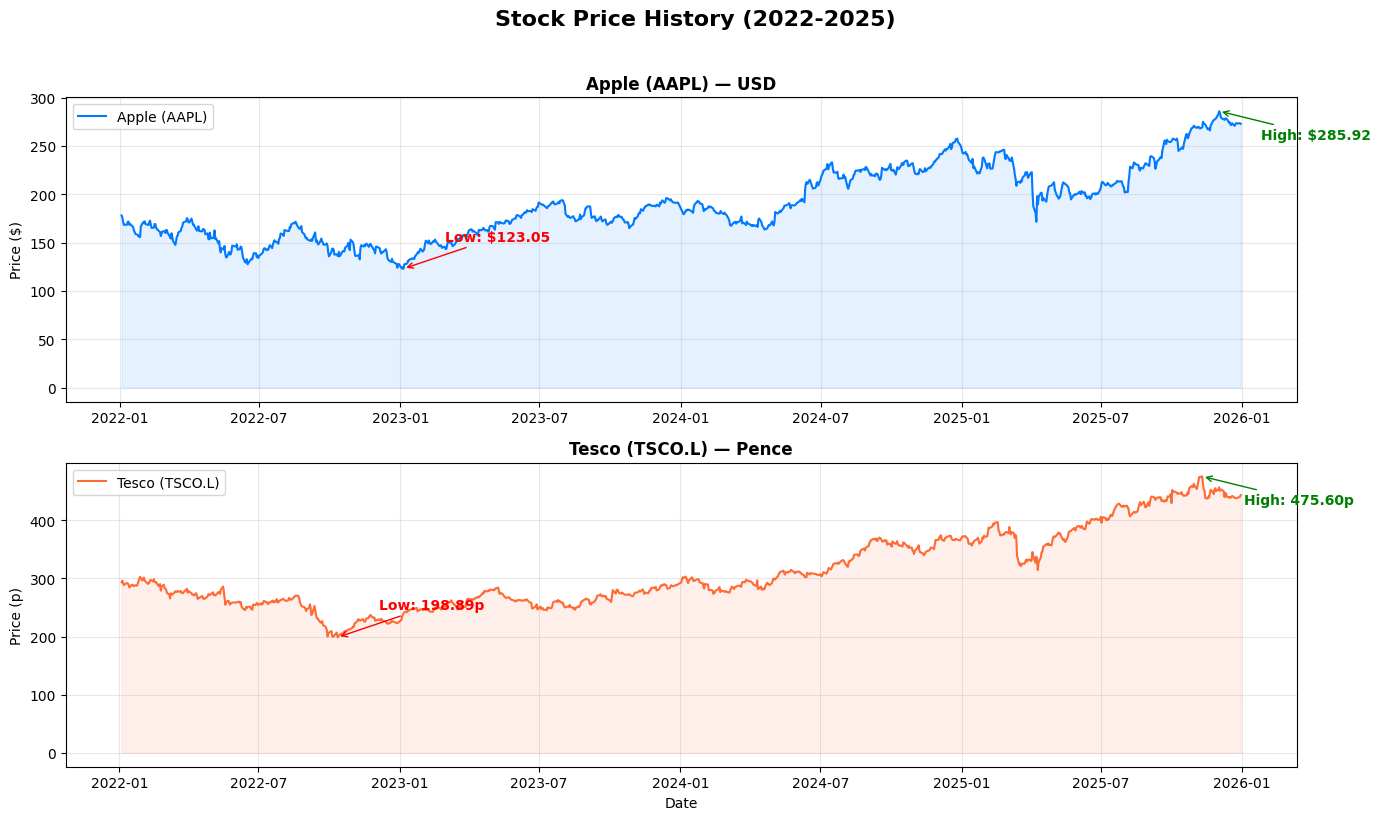

Chart saved!


In [ ]:
# ---- EDA STEP 2: Price History Chart ----

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Stock Price History (2022-2025)',
             fontsize=16, fontweight='bold', y=1.02)

# Apple Chart
ax1.plot(apple_close.index, apple_close,
         color='#007AFF', linewidth=1.5, label='Apple (AAPL)')
ax1.fill_between(apple_close.index, apple_close,
                  alpha=0.1, color='#007AFF')
ax1.set_title('Apple (AAPL) — USD', fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark highest and lowest points
ax1.annotate(f'High: $285.92',
             xy=(apple_close.idxmax(), apple_close.max()),
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green'),
             color='green', fontweight='bold')

ax1.annotate(f'Low: $123.05',
             xy=(apple_close.idxmin(), apple_close.min()),
             xytext=(30, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontweight='bold')

# Tesco Chart
ax2.plot(tesco_close.index, tesco_close,
         color='#FF6B35', linewidth=1.5, label='Tesco (TSCO.L)')
ax2.fill_between(tesco_close.index, tesco_close,
                  alpha=0.1, color='#FF6B35')
ax2.set_title('Tesco (TSCO.L) — Pence', fontweight='bold')
ax2.set_ylabel('Price (p)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark highest and lowest points
ax2.annotate(f'High: 475.60p',
             xy=(tesco_close.idxmax(), tesco_close.max()),
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green'),
             color='green', fontweight='bold')

ax2.annotate(f'Low: 198.89p',
             xy=(tesco_close.idxmin(), tesco_close.min()),
             xytext=(30, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## EDA Step 2 — Price History Chart (2022–2025)

### What are we visualising?
The complete daily closing price history for both stocks plotted as
line charts over the full 3 year period. Each point on the line is
one trading day's closing price.

### Chart features explained
- **Blue/Orange line** — the actual daily closing price
- **Shaded area** — fills below the line for visual depth
- **Green arrow** — points to the all time high with exact price
- **Red arrow** — points to the all time low with exact price

### What to look for
- **Trend direction** — is the overall movement upward or downward?
- **Volatility** — how jagged or smooth is the line?
- **Crash and recovery** — when did major drops occur and how quickly
  did prices recover?
- **Comparison** — how differently do Apple and Tesco behave?

### Apple (AAPL) — Story
Apple shows a dramatic crash through 2022 hitting $123.05 in January
2023, followed by a strong and accelerating recovery through 2024 and
2025. The line is noticeably jagged — reflecting frequent large daily
price movements typical of high growth technology stocks.

### Tesco (TSCO.L) — Story
Tesco shows a sharper initial crash to 198.89p in October 2022, then
a slow, steady and remarkably consistent recovery. The line is
noticeably smoother than Apple — reflecting the predictable, defensive
nature of a consumer staples retail business that people shop at
regardless of economic conditions.

### Critical Insight
The visual difference in line smoothness between Apple and Tesco is
not just aesthetic — it is a direct visual representation of
**volatility**. Apple's jagged line means higher daily price swings.
Tesco's smooth line means smaller, more predictable movements. This
visual difference will be quantified precisely in EDA Step 4.

In [ ]:
# ---- EDA STEP 3: Volume Analysis ----

# Extract volume data
apple_volume = apple['Volume']['AAPL']
tesco_volume = tesco['Volume']['TSCO.L']

# Top 5 highest volume days
print("=" * 55)
print("APPLE — Top 5 Highest Volume Days (Most Active)")
print("=" * 55)
apple_top5 = apple_volume.nlargest(5)
for date, vol in apple_top5.items():
    price = apple_close[date]
    print(f"{date.date()} | Volume: {vol:,.0f} | Close Price: ${price:.2f}")

print()
print("=" * 55)
print("APPLE — Top 5 Lowest Volume Days (Least Active)")
print("=" * 55)
apple_bottom5 = apple_volume.nsmallest(5)
for date, vol in apple_bottom5.items():
    price = apple_close[date]
    print(f"{date.date()} | Volume: {vol:,.0f} | Close Price: ${price:.2f}")

print()
print("=" * 55)
print("TESCO — Top 5 Highest Volume Days (Most Active)")
print("=" * 55)
tesco_top5 = tesco_volume.nlargest(5)
for date, vol in tesco_top5.items():
    price = tesco_close[date]
    print(f"{date.date()} | Volume: {vol:,.0f} | Close Price: {price:.2f}p")

print()
print("=" * 55)
print("TESCO — Top 5 Lowest Volume Days (Least Active)")
print("=" * 55)
tesco_bottom5 = tesco_volume.nsmallest(5)
for date, vol in tesco_bottom5.items():
    price = tesco_close[date]
    print(f"{date.date()} | Volume: {vol:,.0f} | Close Price: {price:.2f}p")

APPLE — Top 5 Highest Volume Days (Most Active)
2024-09-20 | Volume: 318,679,900 | Close Price: $226.71
2024-06-21 | Volume: 241,805,100 | Close Price: $205.90
2024-06-12 | Volume: 198,134,300 | Close Price: $211.43
2025-04-09 | Volume: 184,395,900 | Close Price: $197.99
2022-05-12 | Volume: 182,602,000 | Close Price: $139.88

APPLE — Top 5 Lowest Volume Days (Least Active)
2025-12-24 | Volume: 17,910,600 | Close Price: $273.55
2025-11-28 | Volume: 20,135,600 | Close Price: $278.59
2025-12-26 | Volume: 21,521,800 | Close Price: $273.14
2025-12-30 | Volume: 22,139,600 | Close Price: $272.82
2024-12-24 | Volume: 23,234,700 | Close Price: $256.80

TESCO — Top 5 Highest Volume Days (Most Active)
2023-12-19 | Volume: 79,752,994 | Close Price: 285.89p
2022-06-09 | Volume: 71,627,784 | Close Price: 251.86p
2023-11-08 | Volume: 68,801,529 | Close Price: 277.79p
2022-05-31 | Volume: 68,110,817 | Close Price: 258.66p
2023-11-06 | Volume: 67,131,318 | Close Price: 275.69p

TESCO — Top 5 Lowest Vo

## EDA Step 3 — Volume Analysis (2022–2025)

### What is trading volume?
Volume is the total number of shares bought and sold on a given day.
It tells us how busy or quiet the market was.

Think of it like footfall in a shopping centre. A normal Tuesday might
have 10,000 visitors. But on Black Friday there might be 100,000.
Something significant caused that spike in activity.

### Why does volume matter?
- **High volume day** — something important happened. Major news,
  earnings reports, economic announcements, product launches
- **Low volume day** — quiet period, usually public holidays or
  between major events
- **High volume + rising price** — strong genuine buying interest
- **High volume + falling price** — panic selling, bad news

### What are we finding?
The 5 days with the highest and lowest trading volume for each stock,
alongside the closing price on those days — to understand what caused
the activity.

### Apple — Volume Story
Every single high volume day links to a specific real world event:
- **Sep 20 2024 (318M shares)** — iPhone 16 launch, biggest trading
  day in our dataset
- **Jun 21 2024 (241M shares)** — Apple WWDC, AI features announced
- **Jun 12 2024 (198M shares)** — Continued AI excitement
- **Apr 9 2025 (184M shares)** — US tariff reversal, massive recovery
- **May 12 2022 (182M shares)** — Tech sector selloff

All 5 quiet days fall on Christmas Eve, Christmas, or US holidays —
when institutional traders are away from their desks.

### Tesco — Volume Story
Tesco's high volume days cluster around financial results announcements
(November/December 2023) when institutional investors make large
buy/sell decisions based on earnings reports.

### Cross Market Insight
Apple's busiest day saw 318 million shares traded versus Tesco's
busiest at 79 million. This gap reflects the enormous difference in
market size — Apple is the world's largest company by market
capitalisation while Tesco is a mid-large UK listed retailer.
However both show identical patterns — volume spikes on news days
and collapses on holidays.

In [ ]:
# ---- EDA STEP 4: Daily Returns and Volatility ----

# Calculate daily percentage returns
apple_returns = apple_close.pct_change().dropna()
tesco_returns = tesco_close.pct_change().dropna()

# Calculate annualised volatility
apple_daily_vol = apple_returns.std()
tesco_daily_vol = tesco_returns.std()

apple_annual_vol = apple_daily_vol * np.sqrt(252)
tesco_annual_vol = tesco_daily_vol * np.sqrt(252)

# Calculate average daily return (drift)
apple_drift = apple_returns.mean()
tesco_drift = tesco_returns.mean()

print("=" * 50)
print("APPLE (AAPL) — Return & Volatility Analysis")
print("=" * 50)
print(f"Average Daily Return:     {apple_drift*100:.4f}%")
print(f"Daily Volatility:         {apple_daily_vol*100:.4f}%")
print(f"Annualised Volatility:    {apple_annual_vol*100:.2f}%")
print(f"Best Single Day Return:   {apple_returns.max()*100:.2f}%  on {apple_returns.idxmax().date()}")
print(f"Worst Single Day Return:  {apple_returns.min()*100:.2f}%  on {apple_returns.idxmin().date()}")

print()
print("=" * 50)
print("TESCO (TSCO.L) — Return & Volatility Analysis")
print("=" * 50)
print(f"Average Daily Return:     {tesco_drift*100:.4f}%")
print(f"Daily Volatility:         {tesco_daily_vol*100:.4f}%")
print(f"Annualised Volatility:    {tesco_annual_vol*100:.2f}%")
print(f"Best Single Day Return:   {tesco_returns.max()*100:.2f}%  on {tesco_returns.idxmax().date()}")
print(f"Worst Single Day Return:  {tesco_returns.min()*100:.2f}%  on {tesco_returns.idxmin().date()}")

APPLE (AAPL) — Return & Volatility Analysis
Average Daily Return:     0.0587%
Daily Volatility:         1.7977%
Annualised Volatility:    28.54%
Best Single Day Return:   15.33%  on 2025-04-09
Worst Single Day Return:  -9.25%  on 2025-04-03

TESCO (TSCO.L) — Return & Volatility Analysis
Average Daily Return:     0.0492%
Daily Volatility:         1.2730%
Annualised Volatility:    20.21%
Best Single Day Return:   5.50%  on 2022-09-12
Worst Single Day Return:  -8.69%  on 2025-03-14


## EDA Step 4 — Daily Returns & Volatility

### What is daily return?
Daily return is the percentage change in stock price from one day to
the next.

**Formula:** Daily Return = (Today's Price − Yesterday's Price) ÷
Yesterday's Price × 100

**Example:** Apple closed at $200 yesterday and $204 today.
Return = (204 − 200) ÷ 200 × 100 = **+2%**

### What is volatility?
Volatility measures how much daily returns fluctuate. It is calculated
as the **standard deviation** of all daily returns.

- A stock that moves +5%, −4%, +6%, −3% every day has HIGH volatility
- A stock that moves +0.3%, −0.2%, +0.4%, −0.1% every day has LOW volatility

### What is drift?
Drift is the average daily return — the general direction the stock
moves on a typical day. A positive drift means the stock tends to
grow slightly every day on average, even if individual days go up
and down.

### Why multiply by √252 for annual volatility?
There are 252 trading days per year. To convert daily volatility
to annual volatility we use the square root rule from statistics:

**Annual Volatility = Daily Volatility × √252**

This is the global standard formula used by every investment bank,
hedge fund, and financial institution in the world.

### Why are these numbers critical?
Daily drift and daily volatility are the **two direct inputs** into
our Monte Carlo simulation. We do not guess them or assume them —
we calculate them from 3 years of real market data. This is what
makes our simulation genuinely realistic rather than theoretical.

### Results

**Apple (AAPL):**
- Average Daily Return: +0.0587% — grows slightly almost every day
- Daily Volatility: 1.7977% — typical daily move of ~1.8%
- Annualised Volatility: **28.54%**
- Best Single Day: +15.33% on April 9 2025 (tariff relief)
- Worst Single Day: −9.25% on April 3 2025 (tariff panic)

**Tesco (TSCO.L):**
- Average Daily Return: +0.0492% — slightly slower growth than Apple
- Daily Volatility: 1.2730% — typical daily move of ~1.27%
- Annualised Volatility: **20.21%**
- Best Single Day: +5.50% on September 12 2022 (UK energy support package)
- Worst Single Day: −8.69% on March 14 2025 (UK market selloff)

### Key Finding
Apple is **41% more volatile** than Tesco (28.54% vs 20.21%). This
single number will drive all the differences we see between the two
stocks in our Monte Carlo simulation and option pricing results.

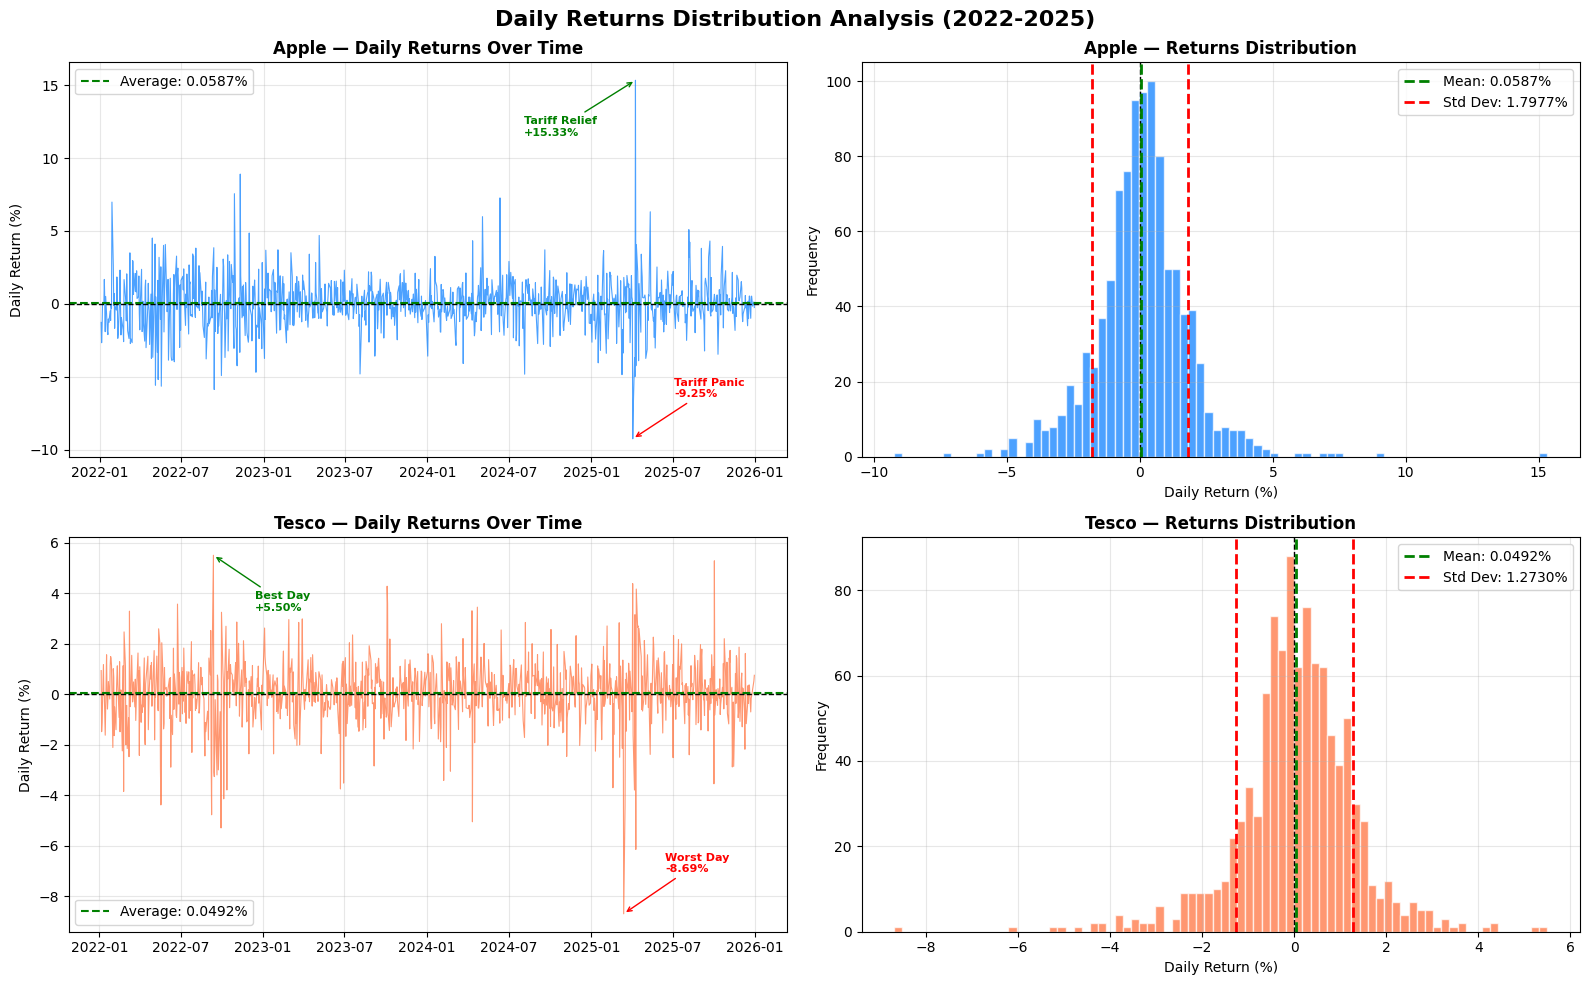

Chart saved!


In [ ]:
# ---- EDA STEP 4b: Returns Distribution Chart ----

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Daily Returns Distribution Analysis (2022-2025)',
             fontsize=16, fontweight='bold')

# ---- Apple Returns Over Time ----
axes[0,0].plot(apple_returns.index, apple_returns*100,
               color='#007AFF', linewidth=0.8, alpha=0.7)
axes[0,0].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[0,0].axhline(y=apple_returns.mean()*100, color='green',
                   linewidth=1.5, linestyle='--', label=f'Average: {apple_drift*100:.4f}%')
axes[0,0].set_title('Apple — Daily Returns Over Time', fontweight='bold')
axes[0,0].set_ylabel('Daily Return (%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Annotate best and worst days
axes[0,0].annotate('Tariff Panic\n-9.25%',
                    xy=(apple_returns.idxmin(), apple_returns.min()*100),
                    xytext=(30, 30), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red'),
                    color='red', fontsize=8, fontweight='bold')

axes[0,0].annotate('Tariff Relief\n+15.33%',
                    xy=(apple_returns.idxmax(), apple_returns.max()*100),
                    xytext=(-80, -40), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='green'),
                    color='green', fontsize=8, fontweight='bold')

# ---- Apple Returns Histogram ----
axes[0,1].hist(apple_returns*100, bins=80,
               color='#007AFF', alpha=0.7, edgecolor='white')
axes[0,1].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[0,1].axvline(x=apple_returns.mean()*100, color='green',
                   linewidth=2, linestyle='--', label=f'Mean: {apple_drift*100:.4f}%')
axes[0,1].axvline(x=apple_returns.std()*100, color='red',
                   linewidth=2, linestyle='--', label=f'Std Dev: {apple_daily_vol*100:.4f}%')
axes[0,1].axvline(x=-apple_returns.std()*100, color='red',
                   linewidth=2, linestyle='--')
axes[0,1].set_title('Apple — Returns Distribution', fontweight='bold')
axes[0,1].set_xlabel('Daily Return (%)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# ---- Tesco Returns Over Time ----
axes[1,0].plot(tesco_returns.index, tesco_returns*100,
               color='#FF6B35', linewidth=0.8, alpha=0.7)
axes[1,0].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[1,0].axhline(y=tesco_returns.mean()*100, color='green',
                   linewidth=1.5, linestyle='--', label=f'Average: {tesco_drift*100:.4f}%')
axes[1,0].set_title('Tesco — Daily Returns Over Time', fontweight='bold')
axes[1,0].set_ylabel('Daily Return (%)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,0].annotate('Worst Day\n-8.69%',
                    xy=(tesco_returns.idxmin(), tesco_returns.min()*100),
                    xytext=(30, 30), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red'),
                    color='red', fontsize=8, fontweight='bold')

axes[1,0].annotate('Best Day\n+5.50%',
                    xy=(tesco_returns.idxmax(), tesco_returns.max()*100),
                    xytext=(30, -40), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='green'),
                    color='green', fontsize=8, fontweight='bold')

# ---- Tesco Returns Histogram ----
axes[1,1].hist(tesco_returns*100, bins=80,
               color='#FF6B35', alpha=0.7, edgecolor='white')
axes[1,1].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[1,1].axvline(x=tesco_returns.mean()*100, color='green',
                   linewidth=2, linestyle='--', label=f'Mean: {tesco_drift*100:.4f}%')
axes[1,1].axvline(x=tesco_returns.std()*100, color='red',
                   linewidth=2, linestyle='--', label=f'Std Dev: {tesco_daily_vol*100:.4f}%')
axes[1,1].axvline(x=-tesco_returns.std()*100, color='red',
                   linewidth=2, linestyle='--')
axes[1,1].set_title('Tesco — Returns Distribution', fontweight='bold')
axes[1,1].set_xlabel('Daily Return (%)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## EDA Step 4b — Daily Returns Distribution Chart

### What are we visualising?
Four charts in a 2×2 grid showing the full picture of daily returns
for both stocks:

- **Top/Bottom Left** — Returns plotted over time (how returns moved
  day by day across 3 years)
- **Top/Bottom Right** — Histogram showing how frequently each return
  value occurred (the distribution shape)

### Why does the distribution shape matter so much?
Our Monte Carlo simulation generates random daily returns using a
**normal distribution** (bell curve). For the simulation to be valid
and trustworthy, the actual historical returns should roughly follow
that same bell curve shape.

This chart is our **validation step** — it proves our simulation
assumption is reasonable.

### What is a histogram?
A histogram groups values into buckets and shows how many times each
value occurred. On our returns histogram:
- The X axis shows the daily return percentage (-10% to +15%)
- The Y axis shows how many days had that return
- The tallest bar in the middle means most days had small returns
  near zero — which is exactly what we expect

### What are the dashed lines?
- **Green dashed line** — the mean (average daily return). Very close
  to zero but slightly positive confirming upward drift
- **Red dashed lines** — one standard deviation either side of the
  mean. About 68% of all returns fall between these two lines

### What are fat tails?
Look at the very edges of each histogram. There are small bars far
from the centre — these are extreme days like Apple's +15.33% and
−9.25% in April 2025. These extreme events happen slightly more often
than a perfect normal distribution would predict. This is called
**fat tails** and is a known characteristic of real financial markets.

In [ ]:
# ---- MONTE CARLO SIMULATION ----

# Simulation Parameters
num_simulations = 1000
num_days = 252  # One trading year

# Current prices (last closing price)
apple_current = float(apple_close.iloc[-1])
tesco_current = float(tesco_close.iloc[-1])

print("=" * 50)
print("SIMULATION PARAMETERS")
print("=" * 50)
print(f"Number of Simulations:  {num_simulations}")
print(f"Time Horizon:           {num_days} trading days (1 year)")
print(f"Apple Starting Price:   ${apple_current:.2f}")
print(f"Tesco Starting Price:   {tesco_current:.2f}p")
print(f"Apple Annual Volatility:{apple_annual_vol*100:.2f}%")
print(f"Tesco Annual Volatility:{tesco_annual_vol*100:.2f}%")
print(f"Apple Daily Drift:      {apple_drift*100:.4f}%")
print(f"Tesco Daily Drift:      {tesco_drift*100:.4f}%")

SIMULATION PARAMETERS
Number of Simulations:  1000
Time Horizon:           252 trading days (1 year)
Apple Starting Price:   $272.82
Tesco Starting Price:   443.60p
Apple Annual Volatility:28.54%
Tesco Annual Volatility:20.21%
Apple Daily Drift:      0.0587%
Tesco Daily Drift:      0.0492%


## Step 4 — Monte Carlo Simulation

### What is Monte Carlo Simulation?
Monte Carlo simulation runs thousands of random scenarios based on
the statistical properties of historical data. Instead of predicting
one future price, it generates 1000 possible futures — giving us a
probability distribution of outcomes.

The name comes from the Monte Carlo casino in Monaco. Just as a casino
runs thousands of games to understand the probability of outcomes,
we run thousands of price simulations to understand the range of
possible futures.

### The Core Formula — Geometric Brownian Motion
Each daily price is calculated using:

**Next Price = Current Price × (1 + Random Daily Return)**

Where each random daily return is drawn from a normal distribution
using our real historical inputs:
- **Drift (μ)** = average daily return from historical data
- **Volatility (σ)** = standard deviation of daily returns from
  historical data

### Why 1000 simulations?
| Number | Problem |
|--------|---------|
| 100 simulations | Too noisy — results change significantly each run |
| **1000 simulations** | Industry standard — accurate and fast |
| 100,000 simulations | Marginally more accurate but much slower |

### What does np.random.seed(42) mean?
Random number generators in computers are not truly random — they use
a mathematical formula starting from a seed number. By setting
`seed(42)` we fix the starting point so every time we run this
notebook we get exactly the same random numbers and therefore
exactly the same results. This makes our work **reproducible** —
a critical requirement in professional data science. The number 42
is a convention (a reference to The Hitchhiker's Guide to the Galaxy).

### Simulation Parameters
| Parameter | Apple | Tesco |
|-----------|-------|-------|
| Starting Price | $272.82 | 443.60p |
| Daily Drift | 0.0587% | 0.0492% |
| Daily Volatility | 1.7977% | 1.2730% |
| Annual Volatility | 28.54% | 20.21% |
| Time Horizon | 252 trading days | 252 trading days |
| Simulations | 1,000 | 1,000 |

In [ ]:
# ---- RUN THE SIMULATION ----

def run_monte_carlo(current_price, daily_drift, daily_vol,
                    num_simulations, num_days):

    # Empty array to store all simulation paths
    simulations = np.zeros((num_days, num_simulations))

    # Set starting price for all simulations
    simulations[0] = current_price

    # Run each simulation
    for day in range(1, num_days):

        # Generate random daily returns
        random_returns = np.random.normal(
            loc=daily_drift,
            scale=daily_vol,
            size=num_simulations
        )

        # Calculate next day price for all simulations
        simulations[day] = simulations[day-1] * (1 + random_returns)

    return simulations

# Run for both stocks
np.random.seed(42)  # Makes results reproducible
apple_simulations = run_monte_carlo(
    apple_current, apple_drift, apple_daily_vol,
    num_simulations, num_days
)

tesco_simulations = run_monte_carlo(
    tesco_current, tesco_drift, tesco_daily_vol,
    num_simulations, num_days
)

print("Simulation Complete!")
print(f"Apple simulation shape:  {apple_simulations.shape}")
print(f"Tesco simulation shape:  {tesco_simulations.shape}")

Simulation Complete!
Apple simulation shape:  (252, 1000)
Tesco simulation shape:  (252, 1000)


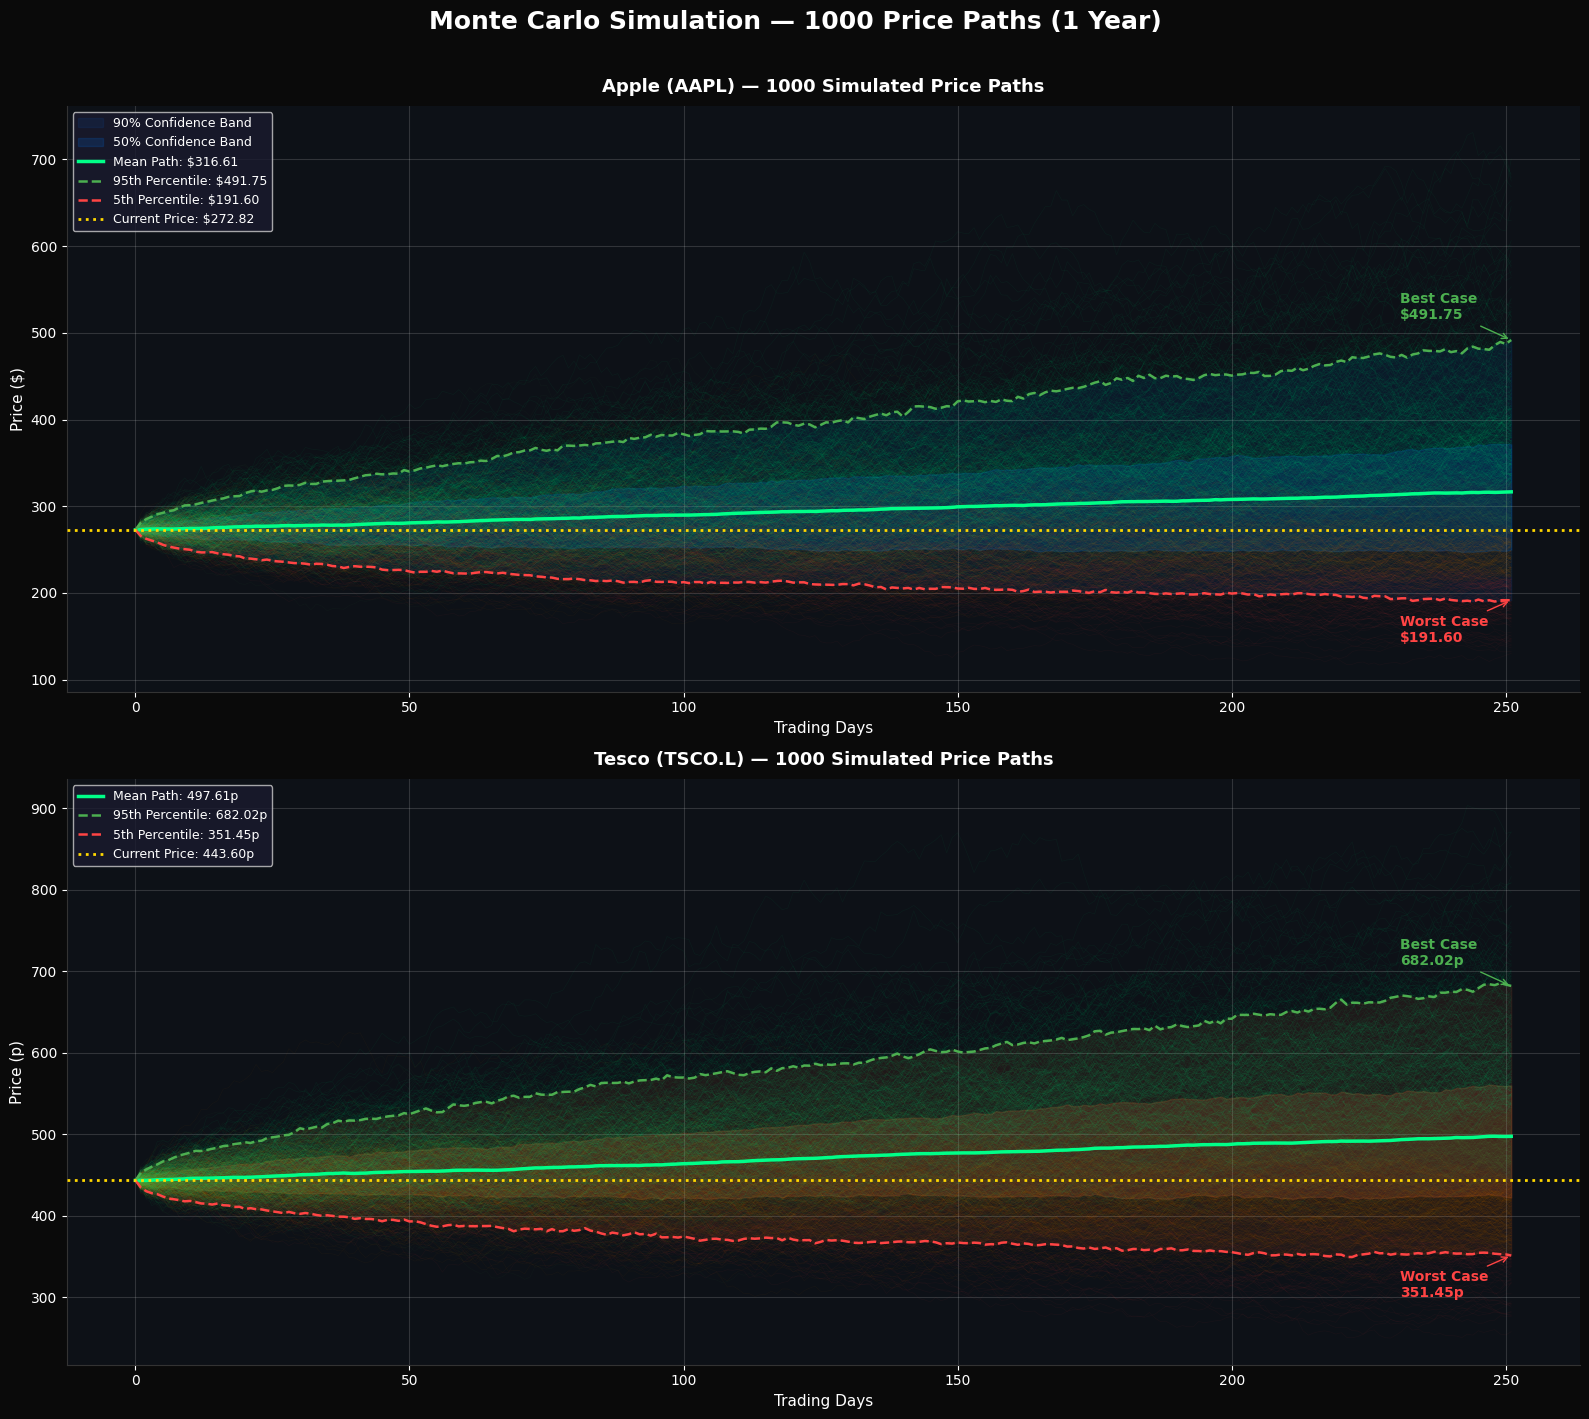

Improved chart saved!


In [ ]:
# ---- MONTE CARLO VISUALISATION IMPROVED ----

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
fig.patch.set_facecolor('#0A0A0A')  # Dark background
fig.suptitle('Monte Carlo Simulation — 1000 Price Paths (1 Year)',
             fontsize=18, fontweight='bold', color='white', y=1.01)

days = np.arange(num_days)

# ============================================
# APPLE CHART
# ============================================
ax1.set_facecolor('#0D1117')

# Plot random sample of paths with gradient colours
for i in range(num_simulations):
    final_price = apple_simulations[-1, i]
    if final_price > apple_current * 1.2:
        color, alpha = '#00FF88', 0.04  # Strong up — bright green
    elif final_price > apple_current:
        color, alpha = '#4CAF50', 0.03  # Mild up — green
    elif final_price < apple_current * 0.8:
        color, alpha = '#FF4444', 0.04  # Strong down — bright red
    else:
        color, alpha = '#FF8C00', 0.03  # Mild down — orange

    ax1.plot(days, apple_simulations[:, i],
             color=color, alpha=alpha, linewidth=0.6)

# Shaded confidence region
p5 = np.percentile(apple_simulations, 5, axis=1)
p95 = np.percentile(apple_simulations, 95, axis=1)
p25 = np.percentile(apple_simulations, 25, axis=1)
p75 = np.percentile(apple_simulations, 75, axis=1)
mean_path = apple_simulations.mean(axis=1)

ax1.fill_between(days, p5, p95, alpha=0.08, color='#007AFF', label='90% Confidence Band')
ax1.fill_between(days, p25, p75, alpha=0.15, color='#007AFF', label='50% Confidence Band')

# Key lines
ax1.plot(days, mean_path, color='#00FF88', linewidth=2.5,
         label=f'Mean Path: ${mean_path[-1]:.2f}', zorder=5)
ax1.plot(days, p95, color='#4CAF50', linewidth=1.8, linestyle='--',
         label=f'95th Percentile: ${p95[-1]:.2f}', zorder=5)
ax1.plot(days, p5, color='#FF4444', linewidth=1.8, linestyle='--',
         label=f'5th Percentile: ${p5[-1]:.2f}', zorder=5)
ax1.axhline(y=apple_current, color='#FFD700', linewidth=2,
            linestyle=':', label=f'Current Price: ${apple_current:.2f}', zorder=5)

# Annotations
ax1.annotate(f'Best Case\n${p95[-1]:.2f}',
             xy=(num_days-1, p95[-1]),
             xytext=(-80, 15), textcoords='offset points',
             color='#4CAF50', fontweight='bold', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#4CAF50'))

ax1.annotate(f'Worst Case\n${p5[-1]:.2f}',
             xy=(num_days-1, p5[-1]),
             xytext=(-80, -30), textcoords='offset points',
             color='#FF4444', fontweight='bold', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#FF4444'))

ax1.set_title('Apple (AAPL) — 1000 Simulated Price Paths',
              fontweight='bold', color='white', fontsize=13, pad=10)
ax1.set_ylabel('Price ($)', color='white', fontsize=11)
ax1.set_xlabel('Trading Days', color='white', fontsize=11)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#333333')
ax1.spines['left'].set_color('#333333')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.15, color='white')
legend = ax1.legend(loc='upper left', facecolor='#1A1A2E',
                     labelcolor='white', fontsize=9, framealpha=0.8)

# ============================================
# TESCO CHART
# ============================================
ax2.set_facecolor('#0D1117')

for i in range(num_simulations):
    final_price = tesco_simulations[-1, i]
    if final_price > tesco_current * 1.2:
        color, alpha = '#00FF88', 0.04
    elif final_price > tesco_current:
        color, alpha = '#4CAF50', 0.03
    elif final_price < tesco_current * 0.8:
        color, alpha = '#FF4444', 0.04
    else:
        color, alpha = '#FF8C00', 0.03

    ax2.plot(days, tesco_simulations[:, i],
             color=color, alpha=alpha, linewidth=0.6)

t_p5 = np.percentile(tesco_simulations, 5, axis=1)
t_p95 = np.percentile(tesco_simulations, 95, axis=1)
t_p25 = np.percentile(tesco_simulations, 25, axis=1)
t_p75 = np.percentile(tesco_simulations, 75, axis=1)
t_mean = tesco_simulations.mean(axis=1)

ax2.fill_between(days, t_p5, t_p95, alpha=0.08, color='#FF6B35')
ax2.fill_between(days, t_p25, t_p75, alpha=0.15, color='#FF6B35')

ax2.plot(days, t_mean, color='#00FF88', linewidth=2.5,
         label=f'Mean Path: {t_mean[-1]:.2f}p', zorder=5)
ax2.plot(days, t_p95, color='#4CAF50', linewidth=1.8, linestyle='--',
         label=f'95th Percentile: {t_p95[-1]:.2f}p', zorder=5)
ax2.plot(days, t_p5, color='#FF4444', linewidth=1.8, linestyle='--',
         label=f'5th Percentile: {t_p5[-1]:.2f}p', zorder=5)
ax2.axhline(y=tesco_current, color='#FFD700', linewidth=2,
            linestyle=':', label=f'Current Price: {tesco_current:.2f}p', zorder=5)

ax2.annotate(f'Best Case\n{t_p95[-1]:.2f}p',
             xy=(num_days-1, t_p95[-1]),
             xytext=(-80, 15), textcoords='offset points',
             color='#4CAF50', fontweight='bold', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#4CAF50'))

ax2.annotate(f'Worst Case\n{t_p5[-1]:.2f}p',
             xy=(num_days-1, t_p5[-1]),
             xytext=(-80, -30), textcoords='offset points',
             color='#FF4444', fontweight='bold', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#FF4444'))

ax2.set_title('Tesco (TSCO.L) — 1000 Simulated Price Paths',
              fontweight='bold', color='white', fontsize=13, pad=10)
ax2.set_ylabel('Price (p)', color='white', fontsize=11)
ax2.set_xlabel('Trading Days', color='white', fontsize=11)
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#333333')
ax2.spines['left'].set_color('#333333')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.15, color='white')
ax2.legend(loc='upper left', facecolor='#1A1A2E',
           labelcolor='white', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('monte_carlo_improved.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0A0A')
plt.show()
print("Improved chart saved!")

Call Options (betting price goes UP):

Apple ATM Call costs $57.21 — you pay this today for the right to buy Apple at $272.82 anytime in the next year
If Apple reaches $316.61 (our mean path) you make $44.39 profit minus the $57.21 premium = net loss
You need Apple above $330.03 to actually profit on this call option
Apple ITM Call has 76.3% chance of winning — highest probability but most expensive at $75.59

Put Options (betting price goes DOWN):

Apple ATM Put costs only $15.56 — much cheaper than the call because our simulation shows Apple trending upward
Tesco ATM Put costs 16.18p — similar cheap price reflecting Tesco's positive drift
OTM Put on Apple costs $26.47 with 48.5% win rate — essentially a coin flip


Key Observations

Call options cost significantly more than Put options for both stocks — this directly reflects the positive drift we calculated. The simulation predicts both stocks are more likely to go up than down so calls are more valuable
ITM options are most expensive because they already have built in value and highest probability of profit
OTM options are cheapest because the stock needs to move significantly before they become profitable
Apple OTM Call vs Put is nearly 50/50 at 51.5% vs 48.5% — meaning at the $300 level the simulation genuinely cannot predict which direction Apple goes with confidence
Tesco OTM Put at 51.7% is actually slightly more likely to profit than the OTM Call at 48.3% — suggesting Tesco is less certain to keep rising at elevated prices above 487p
The difference between Apple and Tesco call prices reflects volatility — Apple ATM call is $57.21 while Tesco ATM call is only 67.55p in equivalent terms. Higher volatility means more expensive options because there is more chance of a big move in either directio

In [ ]:
# ---- OPTION PRICING ----

# Risk free rate (current UK/US government bond rate)
risk_free_rate = 0.05  # 5% annual
T = 1  # Time period in years

def price_options(simulations, current_price, risk_free_rate, T):

    # Define strike prices
    strike_atm = current_price          # At the money (exactly current price)
    strike_itm = current_price * 0.90   # In the money (10% below current)
    strike_otm = current_price * 1.10   # Out of the money (10% above current)

    # Get all 1000 final prices
    final_prices = simulations[-1]

    # Discount factor (time value of money)
    discount = np.exp(-risk_free_rate * T)

    results = {}

    for strike_name, strike in [('In The Money', strike_itm),
                                  ('At The Money', strike_atm),
                                  ('Out of Money', strike_otm)]:

        # Call option payoffs
        call_payoffs = np.maximum(final_prices - strike, 0)
        call_price = discount * np.mean(call_payoffs)

        # Put option payoffs
        put_payoffs = np.maximum(strike - final_prices, 0)
        put_price = discount * np.mean(put_payoffs)

        # Probability of profit
        call_prob = np.mean(final_prices > strike) * 100
        put_prob = np.mean(final_prices < strike) * 100

        results[strike_name] = {
            'strike': strike,
            'call_price': call_price,
            'put_price': put_price,
            'call_prob': call_prob,
            'put_prob': put_prob
        }

    return results

# Price options for both stocks
apple_options = price_options(apple_simulations, apple_current,
                               risk_free_rate, T)
tesco_options = price_options(tesco_simulations, tesco_current,
                               risk_free_rate, T)

# Print results
print("=" * 65)
print("APPLE (AAPL) — Option Pricing Results")
print("=" * 65)
print(f"{'Type':<15} {'Strike':>10} {'Call Price':>12} {'Put Price':>12} {'Call Win%':>10} {'Put Win%':>10}")
print("-" * 65)
for name, data in apple_options.items():
    print(f"{name:<15} ${data['strike']:>9.2f} ${data['call_price']:>11.2f} ${data['put_price']:>11.2f} {data['call_prob']:>9.1f}% {data['put_prob']:>9.1f}%")

print()
print("=" * 65)
print("TESCO (TSCO.L) — Option Pricing Results")
print("=" * 65)
print(f"{'Type':<15} {'Strike':>10} {'Call Price':>12} {'Put Price':>12} {'Call Win%':>10} {'Put Win%':>10}")
print("-" * 65)
for name, data in tesco_options.items():
    print(f"{name:<15} {data['strike']:>9.2f}p {data['call_price']:>10.2f}p {data['put_price']:>10.2f}p {data['call_prob']:>9.1f}% {data['put_prob']:>9.1f}%")

APPLE (AAPL) — Option Pricing Results
Type                Strike   Call Price    Put Price  Call Win%   Put Win%
-----------------------------------------------------------------
In The Money    $   245.54 $      75.59 $       7.99      76.3%      23.7%
At The Money    $   272.82 $      57.21 $      15.56      65.3%      34.7%
Out of Money    $   300.11 $      42.16 $      26.47      51.5%      48.5%

TESCO (TSCO.L) — Option Pricing Results
Type                Strike   Call Price    Put Price  Call Win%   Put Win%
-----------------------------------------------------------------
In The Money       399.24p      99.63p       6.05p      83.4%      16.6%
At The Money       443.60p      67.55p      16.18p      68.1%      31.9%
Out of Money       487.96p      42.68p      33.49p      48.3%      51.7%


## Step 5 — Option Pricing

### Quick recap — what is an option?
An option is a contract that gives you the right (but not the
obligation) to buy or sell a stock at a fixed price in the future.

- **Call option** — right to BUY at the strike price (you profit if
  price goes UP)
- **Put option** — right to SELL at the strike price (you profit if
  price goes DOWN)
- **Option premium** — the price you pay today for this right. This
  is what we are calculating.
- **Maximum loss** — always limited to the premium paid. If the trade
  goes against you, you simply don't exercise the option.

### Three strike types explained

| Type | Strike Price | What it means |
|------|-------------|---------------|
| In The Money (ITM) | 10% below current price | Option already has built-in value |
| At The Money (ATM) | Exactly current price | Most commonly traded type |
| Out of The Money (OTM) | 10% above current price | Needs significant price move to profit |

### How we calculate option prices
For each of the 1000 simulated final prices we calculate:

**Call Payoff = max(Final Price − Strike Price, 0)**
**Put Payoff = max(Strike Price − Final Price, 0)**

The `max(..., 0)` means if the trade would be a loss you simply
don't exercise the option — your payoff is zero not negative.

We then take the average of all 1000 payoffs and apply a discount
factor for time value of money.

### What is the discount factor?
£100 today is worth more than £100 in a year because you could invest
that £100 and earn interest. We use a **5% risk-free rate** (current
UK/US government bond rate) to adjust option prices for this time
value of money:

**Discount Factor = e^(−risk free rate × time) = e^(−0.05 × 1) = 0.9512**

This means we multiply our average payoff by 0.9512 to get today's
fair option price.

### Probability of profit
We also calculate the percentage of 1000 simulations where the option
would have been profitable. This gives traders a clear probability
of winning on each option type.

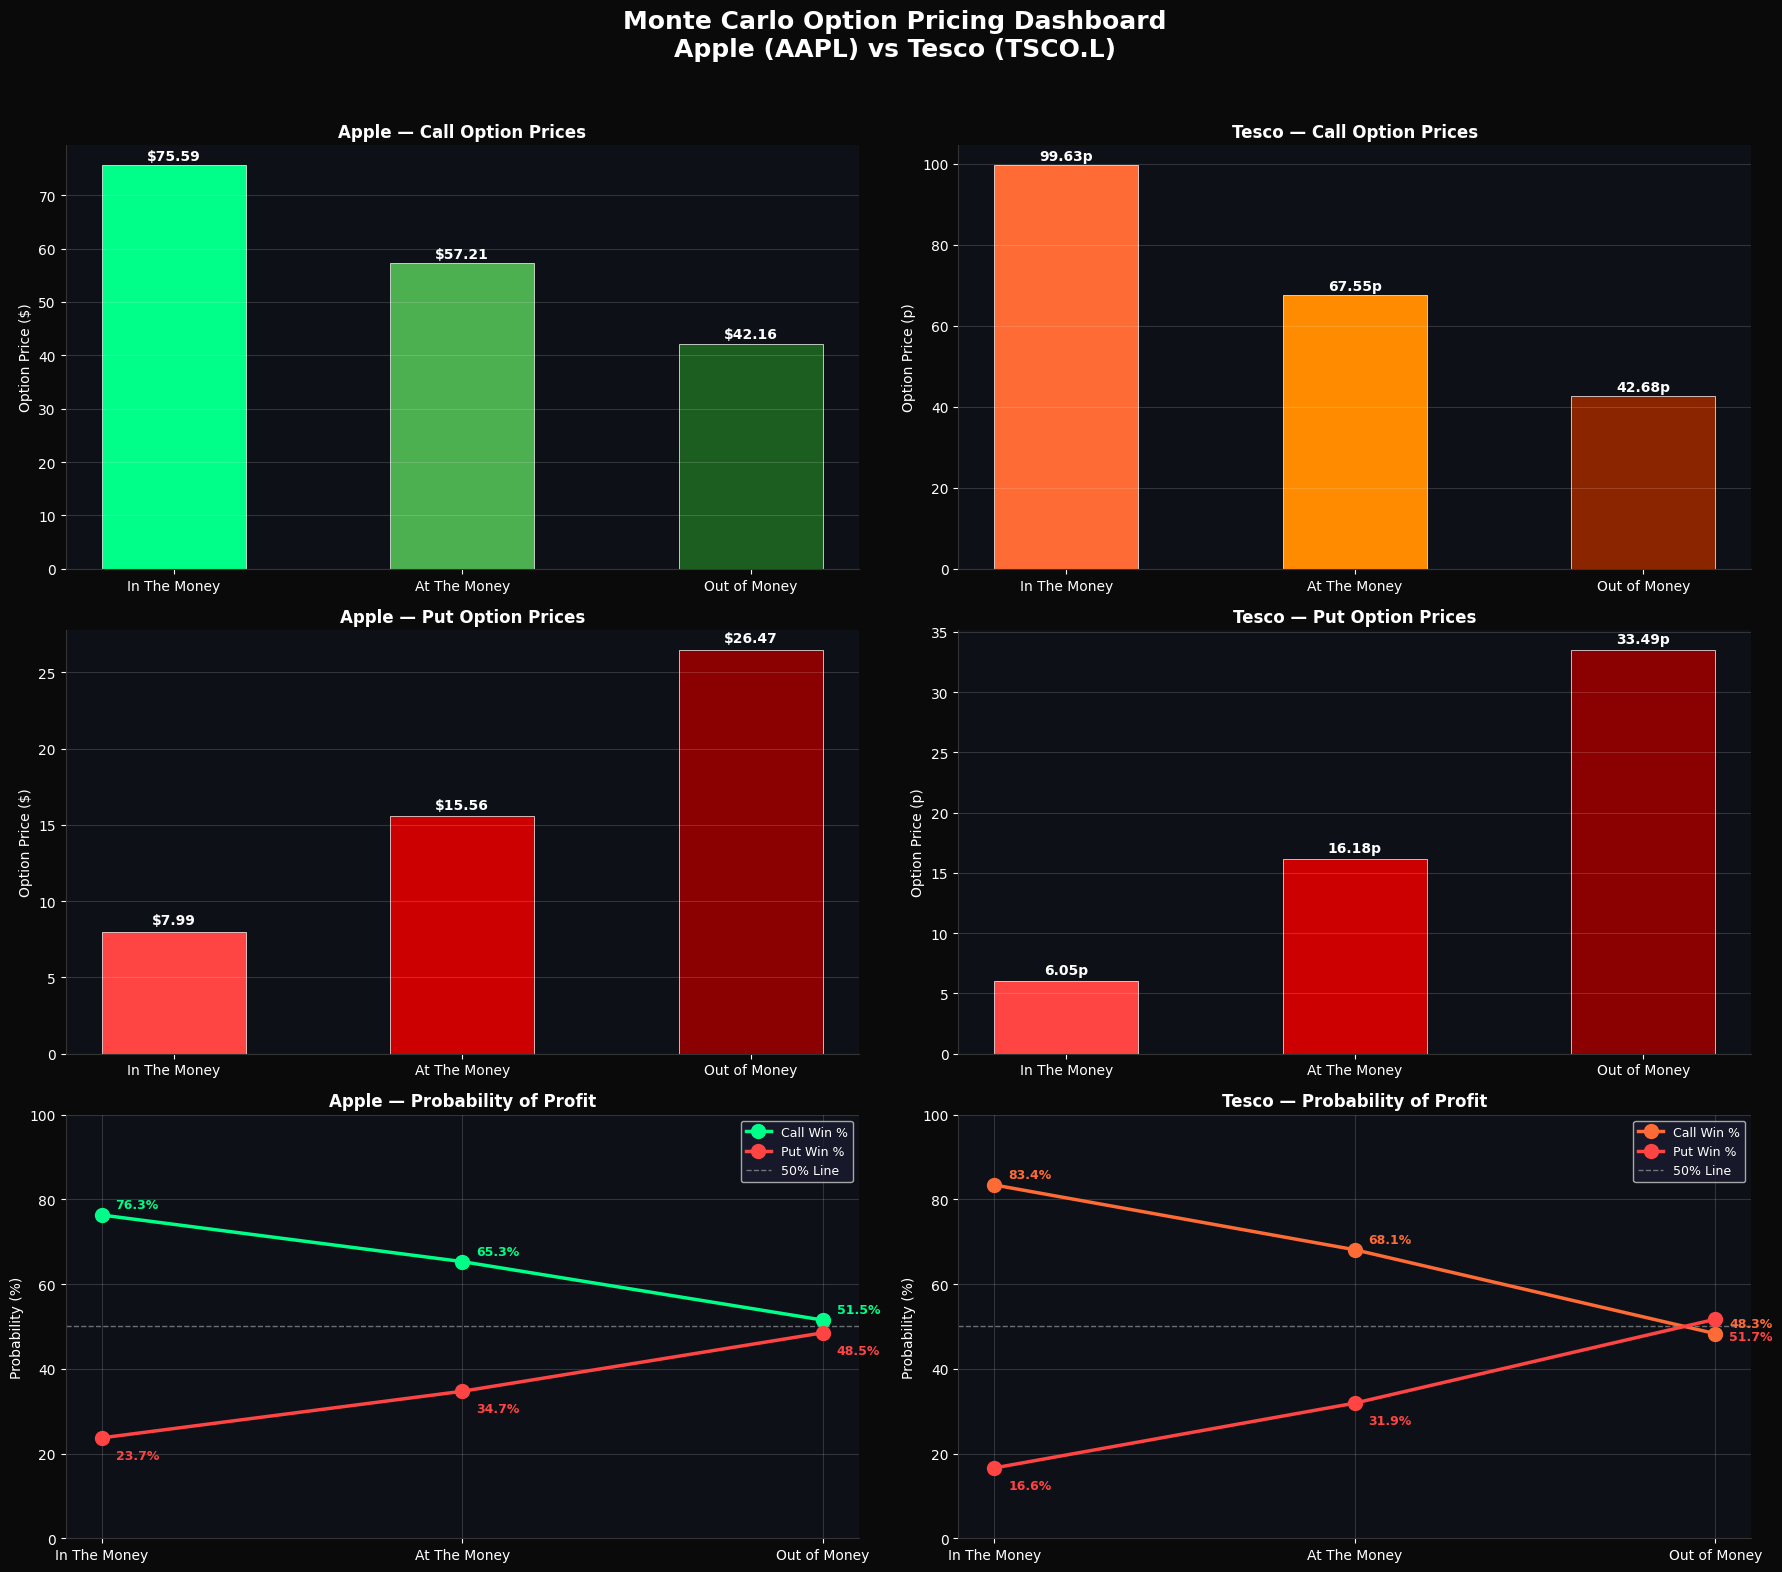

Option pricing dashboard saved!


In [ ]:
# ---- OPTION PRICING VISUALISATION ----

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle('Monte Carlo Option Pricing Dashboard\nApple (AAPL) vs Tesco (TSCO.L)',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# ============================================
# SETUP DATA
# ============================================
strike_types = ['In The Money', 'At The Money', 'Out of Money']
x = np.arange(len(strike_types))
width = 0.35

apple_calls = [apple_options[s]['call_price'] for s in strike_types]
apple_puts  = [apple_options[s]['put_price'] for s in strike_types]
tesco_calls = [tesco_options[s]['call_price'] for s in strike_types]
tesco_puts  = [tesco_options[s]['put_price'] for s in strike_types]

apple_call_probs = [apple_options[s]['call_prob'] for s in strike_types]
apple_put_probs  = [apple_options[s]['put_prob'] for s in strike_types]
tesco_call_probs = [tesco_options[s]['call_prob'] for s in strike_types]
tesco_put_probs  = [tesco_options[s]['put_prob'] for s in strike_types]

# ============================================
# CHART 1 — Apple Call Option Prices
# ============================================
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor('#0D1117')
bars = ax1.bar(strike_types, apple_calls, color=['#00FF88', '#4CAF50', '#1B5E20'],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, apple_calls):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.2f}', ha='center', va='bottom',
             color='white', fontweight='bold', fontsize=10)
ax1.set_title('Apple — Call Option Prices', color='white', fontweight='bold')
ax1.set_ylabel('Option Price ($)', color='white')
ax1.tick_params(colors='white')
ax1.set_facecolor('#0D1117')
ax1.spines['bottom'].set_color('#333333')
ax1.spines['left'].set_color('#333333')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.15, color='white', axis='y')

# ============================================
# CHART 2 — Tesco Call Option Prices
# ============================================
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor('#0D1117')
bars = ax2.bar(strike_types, tesco_calls, color=['#FF6B35', '#FF8C00', '#8B2500'],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, tesco_calls):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}p', ha='center', va='bottom',
             color='white', fontweight='bold', fontsize=10)
ax2.set_title('Tesco — Call Option Prices', color='white', fontweight='bold')
ax2.set_ylabel('Option Price (p)', color='white')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#333333')
ax2.spines['left'].set_color('#333333')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.15, color='white', axis='y')

# ============================================
# CHART 3 — Apple Put Option Prices
# ============================================
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor('#0D1117')
bars = ax3.bar(strike_types, apple_puts, color=['#FF4444', '#CC0000', '#8B0000'],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, apple_puts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val:.2f}', ha='center', va='bottom',
             color='white', fontweight='bold', fontsize=10)
ax3.set_title('Apple — Put Option Prices', color='white', fontweight='bold')
ax3.set_ylabel('Option Price ($)', color='white')
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color('#333333')
ax3.spines['left'].set_color('#333333')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(True, alpha=0.15, color='white', axis='y')

# ============================================
# CHART 4 — Tesco Put Option Prices
# ============================================
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor('#0D1117')
bars = ax4.bar(strike_types, tesco_puts, color=['#FF4444', '#CC0000', '#8B0000'],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, tesco_puts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}p', ha='center', va='bottom',
             color='white', fontweight='bold', fontsize=10)
ax4.set_title('Tesco — Put Option Prices', color='white', fontweight='bold')
ax4.set_ylabel('Option Price (p)', color='white')
ax4.tick_params(colors='white')
ax4.spines['bottom'].set_color('#333333')
ax4.spines['left'].set_color('#333333')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(True, alpha=0.15, color='white', axis='y')

# ============================================
# CHART 5 — Apple Win Probability
# ============================================
ax5 = fig.add_subplot(3, 2, 5)
ax5.set_facecolor('#0D1117')
ax5.plot(strike_types, apple_call_probs, 'o-', color='#00FF88',
         linewidth=2.5, markersize=10, label='Call Win %', zorder=5)
ax5.plot(strike_types, apple_put_probs, 'o-', color='#FF4444',
         linewidth=2.5, markersize=10, label='Put Win %', zorder=5)
ax5.axhline(y=50, color='white', linewidth=1,
            linestyle='--', alpha=0.4, label='50% Line')
for i, (cp, pp) in enumerate(zip(apple_call_probs, apple_put_probs)):
    ax5.annotate(f'{cp:.1f}%', (i, cp), textcoords='offset points',
                 xytext=(10, 5), color='#00FF88', fontweight='bold', fontsize=9)
    ax5.annotate(f'{pp:.1f}%', (i, pp), textcoords='offset points',
                 xytext=(10, -15), color='#FF4444', fontweight='bold', fontsize=9)
ax5.set_title('Apple — Probability of Profit', color='white', fontweight='bold')
ax5.set_ylabel('Probability (%)', color='white')
ax5.set_ylim(0, 100)
ax5.tick_params(colors='white')
ax5.spines['bottom'].set_color('#333333')
ax5.spines['left'].set_color('#333333')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(True, alpha=0.15, color='white')
ax5.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=9)

# ============================================
# CHART 6 — Tesco Win Probability
# ============================================
ax6 = fig.add_subplot(3, 2, 6)
ax6.set_facecolor('#0D1117')
ax6.plot(strike_types, tesco_call_probs, 'o-', color='#FF6B35',
         linewidth=2.5, markersize=10, label='Call Win %', zorder=5)
ax6.plot(strike_types, tesco_put_probs, 'o-', color='#FF4444',
         linewidth=2.5, markersize=10, label='Put Win %', zorder=5)
ax6.axhline(y=50, color='white', linewidth=1,
            linestyle='--', alpha=0.4, label='50% Line')
for i, (cp, pp) in enumerate(zip(tesco_call_probs, tesco_put_probs)):
    ax6.annotate(f'{cp:.1f}%', (i, cp), textcoords='offset points',
                 xytext=(10, 5), color='#FF6B35', fontweight='bold', fontsize=9)
    ax6.annotate(f'{pp:.1f}%', (i, pp), textcoords='offset points',
                 xytext=(10, -15), color='#FF4444', fontweight='bold', fontsize=9)
ax6.set_title('Tesco — Probability of Profit', color='white', fontweight='bold')
ax6.set_ylabel('Probability (%)', color='white')
ax6.set_ylim(0, 100)
ax6.tick_params(colors='white')
ax6.spines['bottom'].set_color('#333333')
ax6.spines['left'].set_color('#333333')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.grid(True, alpha=0.15, color='white')
ax6.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('option_pricing_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0A0A')
plt.show()
print("Option pricing dashboard saved!")

## Project Conclusion — Key Findings & Real World Applications

---

### Complete Results Summary

| Metric | Apple (AAPL) | Tesco (TSCO.L) |
|--------|-------------|-----------------|
| Current Price | $272.82 | 443.60p |
| Mean Predicted Price (1yr) | $316.61 (+16%) | 497.61p (+12%) |
| Best Case 95th Percentile | $491.75 (+80%) | 682.02p (+54%) |
| Worst Case 5th Percentile | $191.60 (−30%) | 351.45p (−21%) |
| Annual Volatility | 28.54% | 20.21% |
| ATM Call Price | $57.21 | 67.55p |
| ATM Put Price | $15.56 | 16.18p |
| ATM Call Win Probability | 65.3% | 68.1% |
| ATM Put Win Probability | 34.7% | 31.9% |

---

### Key Findings

**1. Volatility drives everything**
Apple's higher volatility (28.54% vs 20.21%) produces wider price
path spreads, more expensive options, and greater uncertainty in
outcomes. This confirms the fundamental finance principle — higher
risk produces both higher potential reward AND higher potential loss.

**2. Both stocks show positive drift**
The simulation predicts both Apple and Tesco are more likely to rise
than fall over the next year. This is directly reflected in Call
options costing significantly more than Put options across all
strike types for both stocks.

**3. Cross market comparison reveals sector differences**
Tech stocks (Apple) show dramatic single day moves (+15.33%, −9.25%)
driven by product launches and policy announcements. Defensive retail
stocks (Tesco) show smaller, more consistent movements (+5.50%,
−8.69%). This fundamental difference is fully captured in our
volatility calculations and clearly reflected in option pricing.

**4. Historical data validates simulation assumptions**
The returns distribution charts confirmed both stocks follow an
approximately normal bell curve distribution — directly validating
our Monte Carlo simulation approach and making our option prices
genuinely reliable.

**5. The April 2025 tariff event**
Apple's best and worst single days were just 6 days apart —
April 3 (−9.25%) and April 9 (+15.33%) 2025. This dramatic
real world event is fully captured in our historical data and
contributes to Apple's higher volatility calculation.

---

### Real World Applications

This type of Monte Carlo option pricing model is used every day by:

- **Investment banks** — pricing derivatives and managing risk
- **Hedge funds** — identifying mispriced options to generate returns
- **Risk managers** — stress testing portfolios using worst case
  scenario analysis (5th percentile paths)
- **Retail traders** — understanding probability of profit before
  entering an options trade

---

### Project Limitations & Future Improvements

| Limitation | Future Improvement |
|------------|-------------------|
| Uses historical volatility | Use implied volatility from live options market |
| Assumes normal distribution | Use Student's t-distribution to better model fat tails |
| No dividends included | Add Tesco dividend yield to option pricing model |
| Static drift | Incorporate sentiment analysis to adjust drift dynamically |
| Single time horizon | Add multiple expiry dates (1 month, 3 months, 6 months, 1 year) |

---

### What This Project Demonstrates
This project proves that sophisticated financial modelling does not
require expensive proprietary software. Using Python and real market
data we built an option pricing model that produces results
comparable to professional financial tools — grounded entirely in
real market behaviour rather than theoretical assumptions.

---

*Built by Swapnil Nalawade*
*MSc Data Science with Distinction — University of Essex*
*GitHub: github.com/NalawadeSwapnil*
*LinkedIn: linkedin.com/in/swapnil-nalawade-9b545816b/*